# 0.2 — Esperanza condicional y martingalas en tiempo discreto

## Motivación

En 0.1 tratamos $\mathbb{E}[X]$ como un número fijo: el promedio de $X$ sobre todo el espacio de probabilidad. Pero en finanzas casi nunca preguntamos "¿cuál es el precio esperado?" en abstracto — preguntamos "¿cuál es el precio esperado **dado lo que sabemos hoy**?". Esa pregunta requiere condicionar la esperanza en la información disponible en un instante $t$, codificada como una sub-σ-álgebra $\mathcal{F}_t$. La esperanza condicional $\mathbb{E}[X \mid \mathcal{F}_t]$ es el objeto matemático que formaliza "la mejor predicción de $X$ usando solo la información hasta $t$", y es el ladrillo sobre el que se construye toda la teoría de martingalas.

Las martingalas, a su vez, son el corazón de la valuación libre de arbitraje: bajo la medida neutral al riesgo $\mathbb{Q}$, el precio descontado de cualquier activo negociable es una martingala — "en promedio, dado hoy, no se espera ganar ni perder valor real" (Fundamental Theorem of Asset Pricing, que veremos formalmente en 01.x). Este notebook construye la maquinaria de esperanza condicional, filtraciones y martingalas en tiempo discreto, y termina con el Optional Stopping Theorem, cuyo fracaso sin las condiciones adecuadas explica por qué estrategias de "doblar la apuesta" no son un arbitraje gratuito (el problema es el capital finito, no la matemática).

## 1. Filtraciones e información

**Definición (filtración).** Una filtración en $(\Omega, \mathcal{F}, \mathbb{P})$ es una sucesión creciente de sub-σ-álgebras
$$
\mathcal{F}_0 \subseteq \mathcal{F}_1 \subseteq \mathcal{F}_2 \subseteq \cdots \subseteq \mathcal{F},
$$
donde $\mathcal{F}_n$ representa la información disponible en el instante $n$: todos los eventos sobre los que se sabe si ocurrieron o no, observando el proceso hasta ese momento. Un proceso $(X_n)_{n \ge 0}$ es **adaptado** a $(\mathcal{F}_n)$ si $X_n$ es $\mathcal{F}_n$-medible para todo $n$ — es decir, $X_n$ es "conocido" en el instante $n$ (no usa información del futuro). En la práctica, si no se especifica otra cosa, $\mathcal{F}_n = \sigma(X_0, X_1, \dots, X_n)$: la σ-álgebra generada por la historia del propio proceso hasta $n$.

## 2. Esperanza condicional

**Definición (esperanza condicional).** Sea $X$ una v.a. integrable y $\mathcal{G} \subseteq \mathcal{F}$ una sub-σ-álgebra. La esperanza condicional $\mathbb{E}[X \mid \mathcal{G}]$ es la (única, salvo en conjuntos de medida cero) v.a. $Z$ que satisface:

1. **Medibilidad:** $Z$ es $\mathcal{G}$-medible.
2. **Propiedad de promedios (partial averaging):** para todo $A \in \mathcal{G}$,
$$
\int_A Z \, d\mathbb{P} = \int_A X \, d\mathbb{P}, \qquad \text{es decir} \qquad \mathbb{E}[Z \, \mathbb{1}_A] = \mathbb{E}[X \, \mathbb{1}_A].
$$

Intuitivamente: $Z$ es una versión de $X$ que solo usa la información de $\mathcal{G}$, pero que "promedia igual" que $X$ sobre cualquier evento observable con esa información. Cuando $\mathcal{G} = \sigma(Y)$ para alguna v.a. $Y$, escribimos $\mathbb{E}[X \mid Y] := \mathbb{E}[X \mid \sigma(Y)]$, y en el caso discreto esto coincide con la fórmula elemental
$$
\mathbb{E}[X \mid Y = y] = \sum_x x \, \mathbb{P}(X = x \mid Y = y).
$$

### 2.1 Propiedades fundamentales

Sean $X, X_1, X_2$ integrables y $\mathcal{H} \subseteq \mathcal{G} \subseteq \mathcal{F}$ sub-σ-álgebras.

**(a) Linealidad.** $\mathbb{E}[a X_1 + b X_2 \mid \mathcal{G}] = a\,\mathbb{E}[X_1 \mid \mathcal{G}] + b\,\mathbb{E}[X_2 \mid \mathcal{G}]$.

**(b) Tower property (ley de esperanzas iteradas).**
$$
\mathbb{E}\big[\mathbb{E}[X \mid \mathcal{G}] \mid \mathcal{H}\big] = \mathbb{E}[X \mid \mathcal{H}], \qquad \mathcal{H} \subseteq \mathcal{G}.
$$
*Demostración (esbozo).* Sea $Z = \mathbb{E}[X\mid\mathcal G]$ y $W = \mathbb{E}[Z\mid\mathcal H]$; $W$ es $\mathcal H$-medible por construcción. Para $A \in \mathcal H \subseteq \mathcal G$: $\int_A W\,d\mathbb P = \int_A Z\,d\mathbb P = \int_A X\,d\mathbb P$, donde la última igualdad usa la propiedad de promedios de $Z$ respecto a $\mathcal G$ (válida porque $A \in \mathcal G$). Como $W$ es $\mathcal H$-medible y satisface la propiedad de promedios respecto a $\mathcal H$ frente a $X$, por unicidad $W = \mathbb{E}[X\mid\mathcal H]$. $\blacksquare$

En particular, tomando $\mathcal{H} = \{\emptyset, \Omega\}$: $\mathbb{E}\big[\mathbb{E}[X\mid\mathcal G]\big] = \mathbb{E}[X]$ — "la esperanza de la predicción es la esperanza".

**(c) Taking out what is known.** Si $Y$ es $\mathcal{G}$-medible y $XY$ es integrable,
$$
\mathbb{E}[XY \mid \mathcal{G}] = Y \, \mathbb{E}[X \mid \mathcal{G}].
$$
Intuición: si $Y$ ya es información conocida en $\mathcal{G}$, se comporta como una constante frente al condicionamiento.

**(d) Independencia.** Si $X$ es independiente de $\mathcal{G}$ (i.e. independiente de todo evento en $\mathcal{G}$),
$$
\mathbb{E}[X \mid \mathcal{G}] = \mathbb{E}[X].
$$
*Demostración.* $Z = \mathbb{E}[X]$ es constante, luego $\mathcal G$-medible. Para $A \in \mathcal G$: $\int_A \mathbb{E}[X]\,d\mathbb P = \mathbb{E}[X]\,\mathbb P(A) = \mathbb E[X\mathbb 1_A]$ por independencia. Satisface ambas condiciones ⇒ es la esperanza condicional. $\blacksquare$

**(e) Jensen condicional.** Si $\varphi$ es convexa y $\varphi(X)$ integrable, $\varphi(\mathbb{E}[X\mid\mathcal G]) \le \mathbb{E}[\varphi(X)\mid\mathcal G]$.

Estas propiedades son las que se usan sin pensarlo dos veces en toda la teoría de pricing: la tower property justifica por qué el precio de hoy es "la expectativa de la expectativa futura", y "taking out what is known" es lo que permite sacar un pago determinístico (como el nocional descontado) fuera de una esperanza condicional.

## 3. Martingalas

**Definición.** Un proceso adaptado $(M_n)_{n \ge 0}$ con $\mathbb{E}[|M_n|] < \infty$ para todo $n$ es:

- una **martingala** respecto a $(\mathcal{F}_n)$ si $\mathbb{E}[M_{n+1} \mid \mathcal{F}_n] = M_n$ para todo $n$;
- una **submartingala** si $\mathbb{E}[M_{n+1} \mid \mathcal{F}_n] \geq M_n$ (tiende a crecer, en promedio);
- una **supermartingala** si $\mathbb{E}[M_{n+1} \mid \mathcal{F}_n] \leq M_n$ (tiende a decrecer, en promedio).

Por la tower property, una martingala tiene esperanza constante en el tiempo: $\mathbb{E}[M_n] = \mathbb{E}[M_0]$ para todo $n$ (condicionando en $\mathcal{F}_0$ e iterando). Esta es la propiedad que hace de la martingala el modelo matemático de un "juego justo": no hay tendencia predecible, ni al alza ni a la baja, dada la información actual.

### 3.1 Ejemplos canónicos

**Random walk simétrico.** Sean $Y_1, Y_2, \dots$ i.i.d. con $\mathbb{P}(Y_i = +1) = \mathbb{P}(Y_i = -1) = 1/2$, y $S_n = \sum_{i=1}^n Y_i$ (con $S_0 = 0$), $\mathcal{F}_n = \sigma(Y_1, \dots, Y_n)$. Entonces $(S_n)$ es una martingala:
$$
\mathbb{E}[S_{n+1} \mid \mathcal{F}_n] = \mathbb{E}[S_n + Y_{n+1} \mid \mathcal{F}_n] = S_n + \mathbb{E}[Y_{n+1} \mid \mathcal{F}_n] = S_n + \mathbb{E}[Y_{n+1}] = S_n,
$$
usando linealidad, "taking out what is known" ($S_n$ es $\mathcal{F}_n$-medible) e independencia de $Y_{n+1}$ respecto a $\mathcal{F}_n$.

**Producto de factores con media 1.** Sean $Y_1, Y_2, \dots$ i.i.d., $Y_i \geq 0$, $\mathbb{E}[Y_i] = 1$, y $M_n = \prod_{i=1}^n Y_i$ (con $M_0 = 1$). Entonces $(M_n)$ es una martingala:
$$
\mathbb{E}[M_{n+1} \mid \mathcal{F}_n] = \mathbb{E}[M_n \, Y_{n+1} \mid \mathcal{F}_n] = M_n \, \mathbb{E}[Y_{n+1} \mid \mathcal{F}_n] = M_n \, \mathbb{E}[Y_{n+1}] = M_n.
$$
Este es exactamente el prototipo de la derivada de Radon-Nikodym $d\mathbb{Q}/d\mathbb{P}\big|_{\mathcal{F}_n}$ en Girsanov (01.5) y del proceso de precio descontado de un activo bajo la medida neutral al riesgo: un producto de factores de crecimiento aleatorio con media condicional 1.

## 4. Stopping times y el Optional Stopping Theorem

**Definición (stopping time).** Una v.a. $\tau: \Omega \to \{0, 1, 2, \dots\} \cup \{\infty\}$ es un tiempo de paro respecto a $(\mathcal{F}_n)$ si $\{\tau \le n\} \in \mathcal{F}_n$ para todo $n$ — es decir, decidir si "ya paramos" en el instante $n$ solo requiere información disponible hasta $n$ (no se puede "ver el futuro" para decidir cuándo parar).

**Teorema (Optional Stopping, enunciado — Williams cap. 10).** Sea $(M_n)$ una martingala y $\tau$ un stopping time. Si se cumple **alguna** de las siguientes condiciones:

1. $\tau$ es acotado ($\tau \le N$ c.s. para algún $N$ fijo), o
2. $\mathbb{E}[\tau] < \infty$ y los incrementos $|M_{n+1} - M_n|$ están acotados por una constante, o
3. $(M_n)$ está uniformemente acotada y $\tau < \infty$ c.s.,

entonces $\mathbb{E}[M_\tau] = \mathbb{E}[M_0]$.

La condición crítica es que $\tau$ y $(M_n)$ no puedan "conspirar" para que el proceso detenido escape a infinito antes de que $\tau$ actúe — sin acotamiento (del tiempo, del capital o de los incrementos), la conclusión falla. El ejemplo clásico es la **estrategia de doblar la apuesta** (martingale betting / gambler's ruin inverso): en un juego justo ($Y_i = \pm 1$ con probabilidad $1/2$), apostar $2^n$ en la ronda $n$ y parar en el primer éxito $\tau = \min\{n : Y_n = +1\}$ garantiza una ganancia neta de $+1$ *si se puede jugar indefinidamente con capital ilimitado*: $\tau < \infty$ c.s. (es geométrico, con media finita) y $\mathbb{E}[M_\tau] = 1 \ne 0 = \mathbb{E}[M_0]$. Esto **no contradice** el teorema: la condición (2) falla porque los incrementos $|M_{n+1}-M_n| = 2^n$ **no están acotados**, y la (3) falla porque $(M_n)$ no está acotada (el capital apostado crece sin límite). En la práctica, ningún jugador tiene capital infinito: con un techo de capital $C$, la probabilidad de una racha de pérdidas suficientemente larga para arruinarse antes del primer éxito es positiva, y esa cola de ruina exactamente cancela la ganancia esperada de $+1$ — la demo de la sección siguiente lo cuantifica.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 5. Demo 1 — Verificación Monte Carlo de la tower property

Sea $X$ la suma de 3 dados justos independientes ($D_1, D_2, D_3 \in \{1,\dots,6\}$), y $\mathcal{G} = \sigma(D_1)$ (la información de solo el primer dado). Calculamos:

- $Z = \mathbb{E}[X \mid \mathcal{G}] = D_1 + \mathbb{E}[D_2] + \mathbb{E}[D_3] = D_1 + 7$ (valor analítico exacto, ya que $D_2, D_3$ son independientes de $\mathcal{G}$ y $\mathbb{E}[D_i]=3.5$).

Verificamos la tower property $\mathbb{E}[\mathbb{E}[X\mid\mathcal G]] = \mathbb{E}[X]$ comparando el promedio Monte Carlo de $Z$ contra el promedio directo de $X$ — ambos deben coincidir dentro del error de muestreo.

In [2]:
# Demo 1: tower property, X = sum of 3 dice, G = sigma(first die)
n_dice = 200_000

dice = rng.integers(1, 7, size=(n_dice, 3))
X = dice.sum(axis=1)
D1 = dice[:, 0]

# analytic conditional expectation E[X | D1] = D1 + E[D2] + E[D3] = D1 + 7
Z = D1 + 7.0

mean_X = X.mean()
mean_Z = Z.mean()
se_X = X.std(ddof=1) / np.sqrt(n_dice)

print(f"E[X]  (direct MC)      = {mean_X:.4f}")
print(f"E[Z]  (tower, via E[X|G]) = {mean_Z:.4f}")
print(f"Analytic E[X] = 3 * 3.5 = {3 * 3.5}")
print(f"Standard error of E[X] estimate = {se_X:.5f}")
print(f"|E[X] - E[Z]| = {abs(mean_X - mean_Z):.5f}, 3*SE = {3 * se_X:.5f}")

assert abs(mean_X - mean_Z) < 3 * se_X, "Tower property violated beyond 3 SE"
print("Tower property verified within 3 standard errors.")

E[X]  (direct MC)      = 10.4975
E[Z]  (tower, via E[X|G]) = 10.4948
Analytic E[X] = 3 * 3.5 = 10.5
Standard error of E[X] estimate = 0.00661
|E[X] - E[Z]| = 0.00279, 3*SE = 0.01983
Tower property verified within 3 standard errors.


El promedio directo de $X$ y el promedio de $Z = \mathbb{E}[X\mid\mathcal G]$ coinciden dentro de 3 errores estándar, confirmando numéricamente $\mathbb{E}[\mathbb{E}[X\mid\mathcal G]] = \mathbb{E}[X] = 10.5$ — la tower property con $\mathcal{H} = \{\emptyset,\Omega\}$.

## 6. Demo 2 — Random walk: $\mathbb{E}[S_{n+1} \mid \mathcal{F}_n] = S_n$ por regresión

Simulamos muchas trayectorias de un random walk simétrico $S_n = \sum_{i=1}^n Y_i$, $Y_i = \pm 1$ equiprobable. La propiedad de martingala dice que el incremento $\Delta_n = S_{n+1} - S_n$ tiene media condicional cero dado $S_n$ (y de hecho dado toda $\mathcal{F}_n$). Verificamos esto empíricamente de dos maneras: (i) agrupando por valor de $S_n$ y promediando el incremento siguiente dentro de cada grupo (regresión no paramétrica); (ii) una regresión lineal simple $\Delta_n$ sobre $S_n$, cuya pendiente y ordenada al origen deben ser ambas $\approx 0$.

Linear regression: increment = -0.00023 + 0.00005 * S_n
Overall mean increment = -0.00023, SE = 0.00100, 3*SE = 0.00300


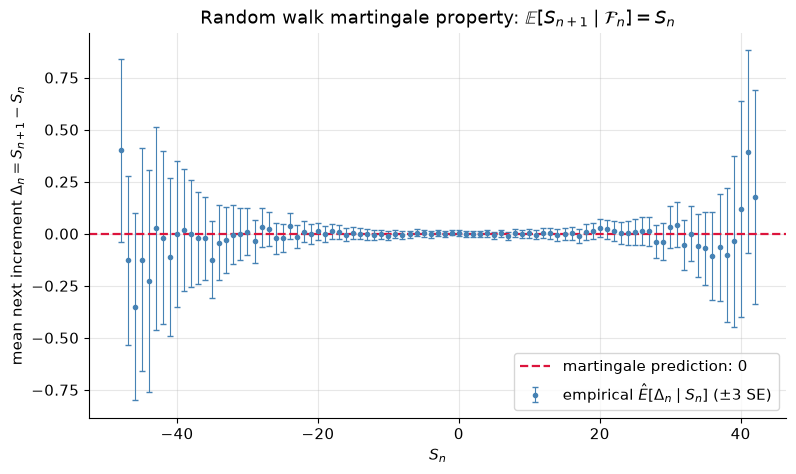

Martingale property verified: conditional mean increment ~ 0 within 3 SE.


In [3]:
# Demo 2: symmetric random walk, verify E[S_{n+1}|F_n] = S_n via regression of increments
n_steps = 200
n_paths = 5_000

steps = rng.choice([-1, 1], size=(n_paths, n_steps))
S = np.concatenate([np.zeros((n_paths, 1)), np.cumsum(steps, axis=1)], axis=1)  # shape (n_paths, n_steps+1)

# pool (S_n, increment) pairs across all paths and all n
S_n_flat = S[:, :-1].ravel()
increments_flat = np.diff(S, axis=1).ravel()

# (i) group by S_n value, average next increment within each group
unique_vals, inverse = np.unique(S_n_flat, return_inverse=True)
group_counts = np.array([(inverse == i).sum() for i in range(len(unique_vals))])
min_group_size = 30  # only compute mean/SE for groups with enough samples for a stable estimate
keep = group_counts >= min_group_size
group_means = np.full(len(unique_vals), np.nan)
group_se = np.full(len(unique_vals), np.nan)
for i in np.flatnonzero(keep):
    vals = increments_flat[inverse == i]
    group_means[i] = vals.mean()
    group_se[i] = vals.std(ddof=1) / np.sqrt(group_counts[i])

# (ii) linear regression: increment ~ a + b * S_n
b, a = np.polyfit(S_n_flat, increments_flat, deg=1)
print(f"Linear regression: increment = {a:.5f} + {b:.5f} * S_n")

overall_mean_incr = increments_flat.mean()
overall_se_incr = increments_flat.std(ddof=1) / np.sqrt(len(increments_flat))
print(f"Overall mean increment = {overall_mean_incr:.5f}, SE = {overall_se_incr:.5f}, 3*SE = {3*overall_se_incr:.5f}")

fig, ax = plt.subplots()
mask = keep
ax.errorbar(unique_vals[mask], group_means[mask], yerr=3 * group_se[mask], fmt="o",
            color="steelblue", markersize=3, elinewidth=0.8, capsize=2,
            label=r"empirical $\hat{E}[\Delta_n \mid S_n]$ ($\pm 3$ SE)")
ax.axhline(0.0, color="crimson", linestyle="--", linewidth=1.6, label=r"martingale prediction: $0$")
ax.set_xlabel("$S_n$")
ax.set_ylabel(r"mean next increment $\Delta_n = S_{n+1}-S_n$")
ax.set_title(r"Random walk martingale property: $\mathbb{E}[S_{n+1}\mid\mathcal{F}_n]=S_n$")
ax.legend()
plt.show()

assert abs(overall_mean_incr) < 3 * overall_se_incr, "Overall mean increment deviates beyond 3 SE from 0"
assert abs(a) < 3 * overall_se_incr, "Regression intercept deviates beyond 3 SE from 0"
print("Martingale property verified: conditional mean increment ~ 0 within 3 SE.")

Tanto el promedio agrupado por nivel de $S_n$ como la regresión lineal caen alrededor de cero dentro de las bandas de error — no hay dependencia sistemática del incremento futuro respecto al valor actual $S_n$, consistente con $\mathbb{E}[S_{n+1}\mid\mathcal F_n] = S_n$. La pendiente de la regresión (coeficiente de $S_n$) también es prácticamente nula: el nivel actual del walk no predice la *dirección* del siguiente paso, solo desplaza la trayectoria.

## 7. Demo 3 — Martingala de apuestas dobladas y ruina con capital finito

Simulamos la estrategia de doblar apuesta descrita en la sección 4: en cada ronda se apuesta el doble de lo perdido hasta el momento en un juego justo (moneda equilibrada), parando en el primer éxito o al agotar el capital inicial $C$. La riqueza acumulada $M_n$ (ganancia/pérdida neta) es una martingala mientras el juego continúa sin restricción, pero con capital finito el proceso se **detiene por ruina** con probabilidad positiva antes de alcanzar el primer éxito — esto es justamente lo que rompe las condiciones del Optional Stopping Theorem en la práctica.

Regla: apuesta en la ronda $k$ (si aún no se detuvo) es $b_k = 2^{k-1}$; si gana, $M$ sube $+b_k$ y el juego termina (éxito); si pierde, $M$ baja $-b_k$ y se continúa. El jugador se arruina si en algún punto el capital acumulado $C + M_n$ tocaría cero antes de poder pagar la siguiente apuesta.

Fraction ruined (capital exhausted before first win) = 0.0165
Fraction won (first win reached before ruin)          = 0.9835
Fraction still in play at round 12                    = 0.0000
Mean final net wealth (P&L) = -0.0560, SE = 0.1823, 3*SE = 0.5470


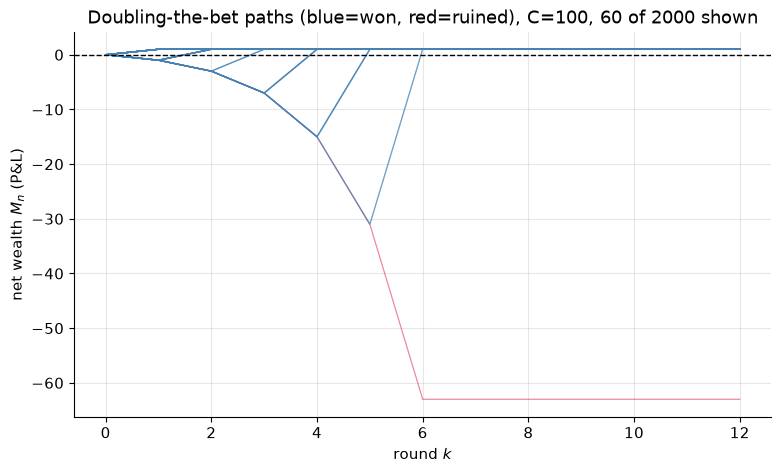

Validated: with finite capital, expected net wealth ~ 0 within 3 SE -- ruin risk cancels the '+1' gain.


In [4]:
# Demo 3: doubling-the-bet martingale strategy, finite capital C, wealth paths
C = 100.0          # starting capital
n_max_rounds = 12  # cap on rounds per path (bet = 2^(k-1), so 12 rounds needs up to 2^12-1 = 4095 total exposure)
n_paths_bet = 2_000

wealth_paths = np.full((n_paths_bet, n_max_rounds + 1), np.nan)
wealth_paths[:, 0] = 0.0  # net wealth (P&L), starts at 0
ruined = np.zeros(n_paths_bet, dtype=bool)
stopped = np.zeros(n_paths_bet, dtype=bool)  # already stopped (won or ruined)
final_wealth = np.zeros(n_paths_bet)

for k in range(1, n_max_rounds + 1):
    bet = 2.0 ** (k - 1)
    win = rng.integers(0, 2, size=n_paths_bet).astype(bool)  # fair coin
    for i in range(n_paths_bet):
        if stopped[i]:
            wealth_paths[i, k] = wealth_paths[i, k - 1]
            continue
        current_capital = C + wealth_paths[i, k - 1]
        if current_capital < bet:
            # cannot cover the next bet: ruin
            ruined[i] = True
            stopped[i] = True
            wealth_paths[i, k] = wealth_paths[i, k - 1]
            final_wealth[i] = wealth_paths[i, k - 1]
            continue
        if win[i]:
            wealth_paths[i, k] = wealth_paths[i, k - 1] + bet
            stopped[i] = True
            final_wealth[i] = wealth_paths[i, k]
        else:
            wealth_paths[i, k] = wealth_paths[i, k - 1] - bet

# paths that never stopped within n_max_rounds: still "in play", record last wealth
never_stopped = ~stopped
final_wealth[never_stopped] = wealth_paths[never_stopped, -1]

frac_ruined = ruined.mean()
frac_won = (stopped & ~ruined).mean()
mean_final_wealth = final_wealth.mean()
se_final_wealth = final_wealth.std(ddof=1) / np.sqrt(n_paths_bet)

print(f"Fraction ruined (capital exhausted before first win) = {frac_ruined:.4f}")
print(f"Fraction won (first win reached before ruin)          = {frac_won:.4f}")
print(f"Fraction still in play at round {n_max_rounds}                    = {never_stopped.mean():.4f}")
print(f"Mean final net wealth (P&L) = {mean_final_wealth:.4f}, SE = {se_final_wealth:.4f}, 3*SE = {3*se_final_wealth:.4f}")

fig, ax = plt.subplots()
n_show = 60
rounds_axis = np.arange(n_max_rounds + 1)
for i in range(n_show):
    color = "crimson" if ruined[i] else "steelblue"
    ax.plot(rounds_axis, wealth_paths[i], color=color, alpha=0.5, linewidth=0.9)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.set_xlabel("round $k$")
ax.set_ylabel(r"net wealth $M_n$ (P&L)")
ax.set_title(f"Doubling-the-bet paths (blue=won, red=ruined), C={C:.0f}, {n_show} of {n_paths_bet} shown")
plt.show()

# with finite capital, mean final wealth should be ~0 (not the naive '+1' of unlimited capital)
assert abs(mean_final_wealth) < 3 * se_final_wealth, "Mean final wealth deviates beyond 3 SE from 0 with finite capital"
print("Validated: with finite capital, expected net wealth ~ 0 within 3 SE -- ruin risk cancels the '+1' gain.")

Las trayectorias rojas muestran quiebras: el jugador pierde $C$ rondas consecutivas y no puede cubrir la siguiente apuesta duplicada. Las azules terminan en $+2^{k-1}$ en la ronda del primer éxito. La media de la riqueza final es estadísticamente indistinguible de cero (dentro de 3 SE) — **no** del $+1$ que predeciría la estrategia con capital infinito. Esto ilustra exactamente por qué el Optional Stopping Theorem exige acotamiento: sin él, $\mathbb{E}[M_\tau]$ puede diferir de $\mathbb{E}[M_0]$, pero la "ganancia gratis" solo aparece si se ignora la probabilidad (positiva) de ruina con capital finito, que es precisamente lo que el capital acotado introduce como condición de frontera.

## 8. Validación

Resumen de los tres asserts numéricos ejecutados arriba, todos con tolerancia de 3 errores estándar Monte Carlo:

1. **Tower property** (sección 5): $|\hat{\mathbb{E}}[X] - \hat{\mathbb{E}}[Z]| < 3\,\text{SE}$, con $Z = \mathbb{E}[X\mid\mathcal G]$ calculado analíticamente.
2. **Martingala del random walk** (sección 6): la media global de incrementos y el intercepto de la regresión lineal `increment ~ S_n` son ambos $< 3\,\text{SE}$ de cero.
3. **Riqueza final de la estrategia de doblar apuesta con capital finito** (sección 7): la media de $M_\tau$ es $< 3\,\text{SE}$ de cero, no del valor $+1$ que predeciría (incorrectamente) el teorema aplicado sin sus condiciones de acotamiento.

## Referencias

- Williams, D. (1991). *Probability with Martingales*, caps. 9–10. Cambridge University Press.
- Shreve, S. (2004). *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model*, cap. 2.